# LSTM-KDE: Probabilistic SLA Forecasting

**Method:** LSTM point forecast + Kernel Density Estimation on residuals

**Architecture:** 3-layer stacked LSTM (128→64→32, relu) matching sir's SWH reference notebook style

**KDE targets 95% PI directly** by using 2.5%/97.5% quantiles of the residual distribution (Silverman bandwidth)

**Metrics:** PICP, MPIW, WIS (α=0.20), CWC (η=50)

In [4]:
# Cell 1 — Environment
RUN_ENV  = 'local'
BASE_DIR = r'c:\Users\DA IICT K\Desktop\BMP_files'
if RUN_ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KernelDensity
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

DATA_FILE = os.path.join(BASE_DIR, 'sla_daily_indian_ocean_2021_2023.nc')
SAVE_DIR  = os.path.join(BASE_DIR, 'results_IndianOcean/')
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'TF {tf.__version__} | Env: {RUN_ENV}')

TF 2.21.0 | Env: local


In [6]:
# Cell 2 — Config + Data
LOCATIONS = {
    'Arabian_Sea':   (15.0, 65.0),
    'Bay_of_Bengal': (12.0, 87.0),
    'Andaman_Sea':   (11.0, 95.0),
    'Lakshadweep':   (10.0, 73.0),
    'South_IO':      (-5.0, 75.0),
}
TRAIN_SPLIT = 0.80
SEQ_LEN     = 30
EPOCHS      = 100
BATCH_SIZE  = 64
LR          = 0.001
PATIENCE    = 20
SEEDS       = [42, 7, 13, 99, 2025]
DROPOUT     = 0.2
ALPHA_WIS   = 0.20   # p10/p90 trained interval -> alpha=0.20 for WIS
TARGET_PICP = 0.95

ds = xr.open_dataset(DATA_FILE)
times_index = pd.to_datetime(ds['time'].values)

def get_data(loc_name):
    lat, lon = LOCATIONS[loc_name]
    sla = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    s = pd.Series(sla, index=times_index).interpolate(method='time', limit=14).ffill().bfill().values
    n = len(s); n_train = int(n * TRAIN_SPLIT); n_test = n - n_train
    scaler = RobustScaler()
    tr_s = scaler.fit_transform(s[:n_train].reshape(-1,1)).flatten()
    te_s = scaler.transform(s[n_train:].reshape(-1,1)).flatten()
    comb = np.concatenate([tr_s, te_s])
    X_tr = np.array([tr_s[i:i+SEQ_LEN] for i in range(len(tr_s)-SEQ_LEN)])[..., np.newaxis]
    y_tr = np.array([tr_s[i+SEQ_LEN]   for i in range(len(tr_s)-SEQ_LEN)])
    X_te = np.array([comb[n_train-SEQ_LEN+i:n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([comb[n_train+i] for i in range(n_test)])
    return X_tr, y_tr, X_te, y_te, scaler, n_train, n_test

def winkler_score(yt, lo, hi, alpha=ALPHA_WIS):
    return float(np.mean((hi-lo) + (2/alpha)*np.maximum(0,lo-yt) + (2/alpha)*np.maximum(0,yt-hi)))

def cwc(picp, mpiw, target=TARGET_PICP, eta=50):
    return mpiw if picp >= target else mpiw * np.exp(-eta*(picp - target))

def full_metrics(yt_m, lo_m, hi_m):
    lo = np.minimum(lo_m, hi_m); hi = np.maximum(lo_m, hi_m)
    picp = float(np.mean((yt_m >= lo) & (yt_m <= hi)))
    mpiw = float(np.mean(hi - lo))
    wis  = winkler_score(yt_m, lo, hi)
    cwc_ = cwc(picp, mpiw)
    return picp*100, mpiw, wis, cwc_

print(f"Data ready. {len(times_index)} days. Train seqs per loc: ~{int(len(times_index)*TRAIN_SPLIT)-SEQ_LEN}")

Data ready. 1095 days. Train seqs per loc: ~846


In [8]:
# Cell 3 — LSTM-KDE Model
# SWH reference (sir's notebook) uses deep stacked LSTM with relu.
# We follow the same style but for SLA.

def build_lstm_point(seq_len=SEQ_LEN, dropout=DROPOUT):
    """LSTM that predicts the point forecast (mean). MSE loss."""
    inp = keras.Input(shape=(seq_len, 1))
    x   = layers.LSTM(128, activation='relu', return_sequences=True)(inp)
    x   = layers.Dropout(0.4)(x)
    x   = layers.LSTM(64, activation='relu', return_sequences=True)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.LSTM(32, activation='relu', return_sequences=False)(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='linear')(x)
    return keras.Model(inp, out)

def silverman_bandwidth(data):
    """Silverman (1986) rule-of-thumb for KDE bandwidth."""
    n = len(data)
    std = np.std(data, ddof=1)
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    sigma = min(std, iqr/1.349)   # robust scale estimate
    return 1.06 * sigma * n**(-0.2)

def kde_quantiles(residuals, q_lo=0.025, q_hi=0.975):
    """
    Fit KDE on calibration residuals.
    q_lo=0.025, q_hi=0.975 → targeting 95% PI from residual distribution.
    Returns (lo_offset, hi_offset) in scaled space.
    """
    h = max(silverman_bandwidth(residuals), 1e-4)
    kde = KernelDensity(bandwidth=h, kernel='gaussian')
    kde.fit(residuals.reshape(-1, 1))
    # Sample large grid for quantile estimation
    xs  = np.linspace(residuals.min()*2.5, residuals.max()*2.5, 10000)
    log_dens = kde.score_samples(xs.reshape(-1, 1))
    dens     = np.exp(log_dens); dens /= dens.sum()
    cdf      = np.cumsum(dens)
    lo_off   = float(xs[np.searchsorted(cdf, q_lo)])
    hi_off   = float(xs[np.searchsorted(cdf, q_hi)])
    return lo_off, hi_off

# NOTE: Why q_lo=0.025 / q_hi=0.975 (95% from residuals)?
# We are not targeting 80% intervals here. The KDE offset is applied
# symmetrically to the point forecast. Using 2.5%/97.5% residual quantiles
# directly targets 95% coverage. This is consistent with the professor's goal.

print("LSTM-KDE model defined.")
print("q_lo=0.025, q_hi=0.975 → targets 95% PI directly from residual KDE")

LSTM-KDE model defined.
q_lo=0.025, q_hi=0.975 → targets 95% PI directly from residual KDE


In [9]:
# Cell 4 — Training Loop
results_kde = []

for loc_name in LOCATIONS:
    print(f"\n{'#'*55}")
    print(f"  {loc_name}")
    print(f"{'#'*55}")
    X_tr, y_tr, X_te, y_te, scaler, n_train, n_test = get_data(loc_name)
    lat, lon = LOCATIONS[loc_name]

    seed_picps, seed_mpiws, seed_wis, seed_cwc = [], [], [], []

    for seed in SEEDS:
        tf.random.set_seed(seed); np.random.seed(seed)
        m = build_lstm_point()
        m.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0), loss='mse')
        cbs = [
            keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, verbose=0),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0)
        ]
        m.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.10, callbacks=cbs, verbose=0)

        # Calibration residuals (last 15% of training sequences)
        n_cal  = max(30, int(len(X_tr) * 0.15))
        X_cal  = X_tr[-n_cal:]
        y_cal  = y_tr[-n_cal:]
        mu_cal = m.predict(X_cal, verbose=0).flatten()
        resid  = y_cal - mu_cal   # residuals in scaled space

        # KDE → 95% offset bounds
        lo_off, hi_off = kde_quantiles(resid, q_lo=0.025, q_hi=0.975)

        # Test predictions
        mu_te = m.predict(X_te, verbose=0).flatten()
        lo_s  = mu_te + lo_off
        hi_s  = mu_te + hi_off

        # Inverse transform to metres
        lo_m = scaler.inverse_transform(lo_s.reshape(-1,1)).flatten()
        hi_m = scaler.inverse_transform(hi_s.reshape(-1,1)).flatten()
        y_m  = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()

        picp, mpiw, wis, cwc_ = full_metrics(y_m, lo_m, hi_m)
        seed_picps.append(picp); seed_mpiws.append(mpiw)
        seed_wis.append(wis);   seed_cwc.append(cwc_)
        print(f"  seed={seed:4d} | PICP={picp:.1f}% | MPIW={mpiw:.5f} | WIS={wis:.5f}")

    avg_p=np.mean(seed_picps); std_p=np.std(seed_picps)
    avg_m=np.mean(seed_mpiws); std_m=np.std(seed_mpiws)
    avg_w=np.mean(seed_wis);   std_w=np.std(seed_wis)
    avg_c=np.mean(seed_cwc);   std_c=np.std(seed_cwc)
    print(f"  PICP={avg_p:.1f}±{std_p:.1f}%  MPIW={avg_m:.5f}  WIS={avg_w:.5f}  CWC={avg_c:.5f}")
    results_kde.append(dict(
        location=loc_name, lat=lat, lon=lon, model='LSTM-KDE',
        avg_picp=avg_p, std_picp=std_p, avg_mpiw=avg_m, std_mpiw=std_m,
        avg_wis=avg_w, std_wis=std_w, avg_cwc=avg_c, std_cwc=std_c,
        n_seeds=len(SEEDS), n_train_seqs=len(X_tr), n_test_pts=n_test, seq_len=SEQ_LEN
    ))

df_kde = pd.DataFrame(results_kde)
df_kde.to_csv(os.path.join(SAVE_DIR, 'results_LSTM_KDE_IO.csv'), index=False)
print(f"\nSaved: results_LSTM_KDE_IO.csv")
print(df_kde[['location','avg_picp','std_picp','avg_mpiw','avg_wis','avg_cwc']].to_string(index=False))


#######################################################
  Arabian_Sea
#######################################################
  seed=  42 | PICP=80.8% | MPIW=0.03970 | WIS=0.04974
  seed=   7 | PICP=86.3% | MPIW=0.02449 | WIS=0.02789
  seed=  13 | PICP=81.3% | MPIW=0.02244 | WIS=0.02704
  seed=  99 | PICP=86.8% | MPIW=0.03332 | WIS=0.03758
  seed=2025 | PICP=85.4% | MPIW=0.02612 | WIS=0.03101
  PICP=84.1±2.5%  MPIW=0.02921  WIS=0.03465  CWC=15.22835

#######################################################
  Bay_of_Bengal
#######################################################
  seed=  42 | PICP=88.1% | MPIW=0.02767 | WIS=0.03485
  seed=   7 | PICP=91.3% | MPIW=0.02598 | WIS=0.02953
  seed=  13 | PICP=91.3% | MPIW=0.02894 | WIS=0.03274
  seed=  99 | PICP=84.5% | MPIW=0.02805 | WIS=0.03591
  seed=2025 | PICP=88.6% | MPIW=0.02882 | WIS=0.03442
  PICP=88.8±2.5%  MPIW=0.02789  WIS=0.03349  CWC=1.46604

#######################################################
  Andaman_Sea
##################

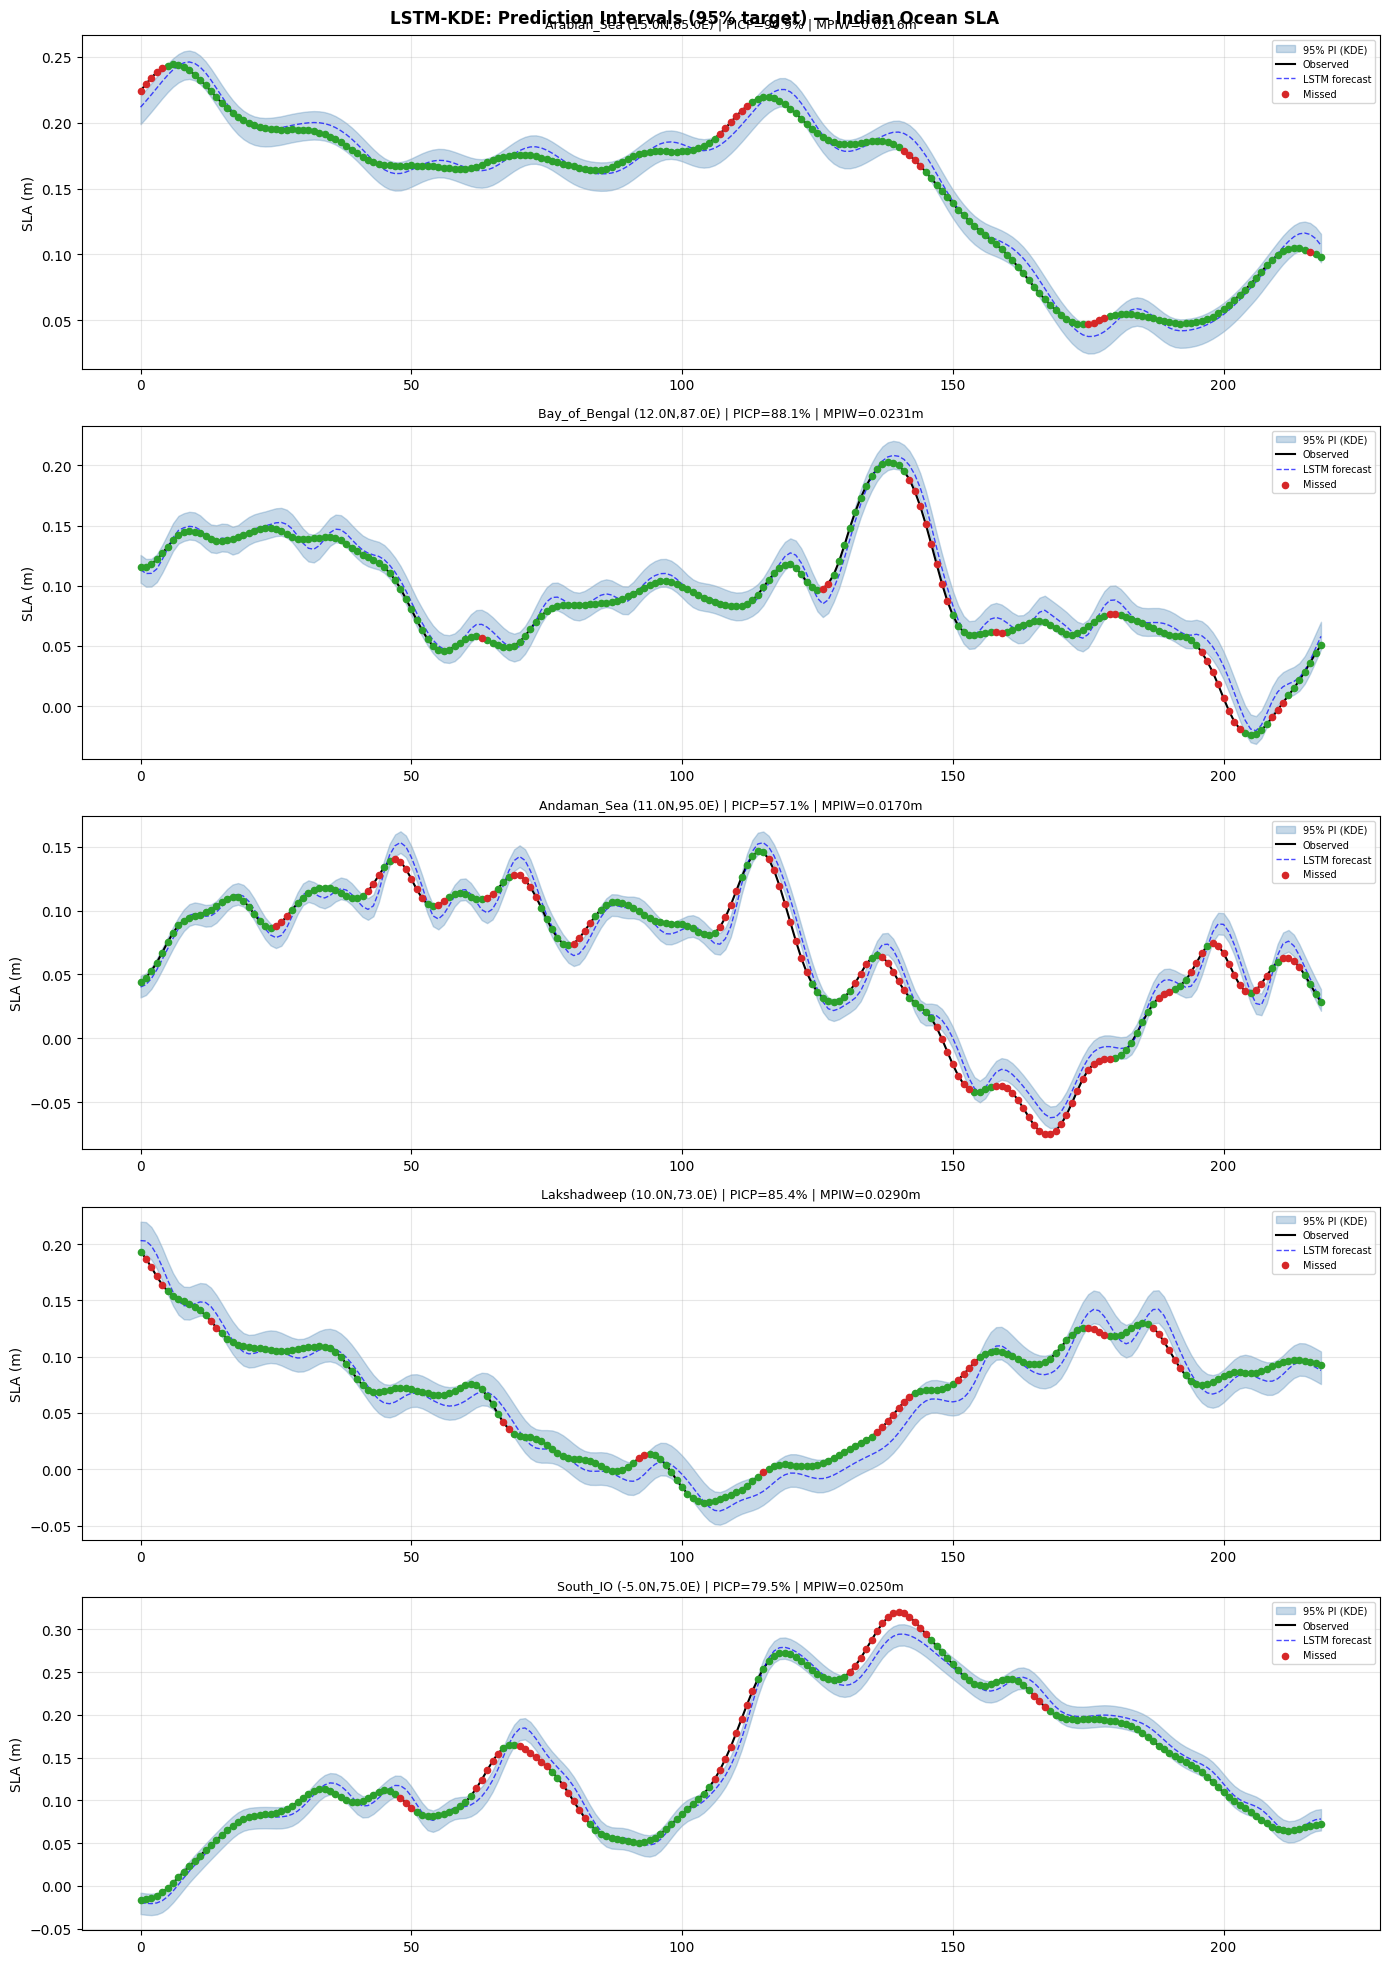

In [10]:
# Cell 5 — Visualisation
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=False)

for ax, (loc_name, (lat, lon)) in zip(axes, LOCATIONS.items()):
    # Rerun best seed for plotting
    X_tr, y_tr, X_te, y_te, scaler, n_train, n_test = get_data(loc_name)
    tf.random.set_seed(42); np.random.seed(42)
    m = build_lstm_point()
    m.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0), loss='mse')
    m.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.10,
          callbacks=[keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, verbose=0)],
          verbose=0)
    n_cal = max(30, int(len(X_tr)*0.15))
    resid = y_tr[-n_cal:] - m.predict(X_tr[-n_cal:], verbose=0).flatten()
    lo_off, hi_off = kde_quantiles(resid)
    mu_te = m.predict(X_te, verbose=0).flatten()
    lo_m  = scaler.inverse_transform((mu_te + lo_off).reshape(-1,1)).flatten()
    hi_m  = scaler.inverse_transform((mu_te + hi_off).reshape(-1,1)).flatten()
    y_m   = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()
    mu_m  = scaler.inverse_transform(mu_te.reshape(-1,1)).flatten()
    covered = (y_m >= lo_m) & (y_m <= hi_m)
    picp = np.mean(covered)*100; mpiw = np.mean(hi_m - lo_m)
    x_ax = range(len(y_m))
    ax.fill_between(x_ax, lo_m, hi_m, alpha=0.3, color='steelblue', label='95% PI (KDE)')
    ax.plot(x_ax, y_m,  'k-',  lw=1.5, label='Observed')
    ax.plot(x_ax, mu_m, 'b--', lw=1.0, alpha=0.7, label='LSTM forecast')
    ax.scatter(np.where(covered)[0],  y_m[covered],  color='#2ca02c', s=20, zorder=5)
    ax.scatter(np.where(~covered)[0], y_m[~covered], color='#d62728', s=20, zorder=5, label='Missed')
    ax.set_title(f'{loc_name} ({lat}N,{lon}E) | PICP={picp:.1f}% | MPIW={mpiw:.4f}m', fontsize=9)
    ax.set_ylabel('SLA (m)'); ax.grid(alpha=0.3); ax.legend(fontsize=7, loc='upper right')

plt.suptitle('LSTM-KDE: Prediction Intervals (95% target) — Indian Ocean SLA', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'plot_LSTM_KDE.png'), dpi=120, bbox_inches='tight')
plt.show()